Prompt para Classificação de Tópicos de Notícias
Instruções para o Modelo:
Você é um classificador de notícias especializado em categorizar textos jornalísticos (títulos ou trechos) em uma das seguintes categorias:

Política

Economia

Saúde

Esportes

Tecnologia

Como responder:

Analise o texto fornecido.

Identifique o tópico principal com base em palavras-chave e contexto.

Retorne apenas o nome da categoria correspondente, sem explicações adicionais.

Exemplos de Entrada e Saída
Entrada (Texto da Notícia)	Saída Esperada
"Senado aprova nova lei de proteção de dados."	Política
"Dólar atinge maior valor em 5 anos."	Economia
"OMS anuncia novas diretrizes para tratamento de câncer."	Saúde
"Brasil vence a Argentina nas quartas da Copa."	Esportes
"Empresa lança chip com IA para smartphones."	Tecnologia
Regras Adicionais:

Se o texto abordar múltiplos tópicos, escolha o mais dominante.

Ignore opiniões ou viés do autor; foque no conteúdo factual.

Para termos ambíguos (ex: "Apple"), considere o contexto (tecnologia vs. economia).

Boas Práticas Aplicadas
Clareza e Especificidade

O prompt define categorias mutuamente exclusivas e inclui exemplos variados.

Justificativa: Reduz erros de classificação e melhora a consistência.

Formato Padronizado

A saída é restrita ao nome da categoria, facilitando integração com sistemas.

Justificativa: Evita ruídos em processamento automatizado (ex: APIs).

Diretrizes para Casos Limítrofes

Regras para textos multitemáticos e ambiguidades lexicais.

Justificativa: Aumenta a robustez em cenários reais.

Reflexão Ética e Conformidade
Transparência e Viés:

O modelo deve ser periodicamente auditado para detectar vieses (ex: associar "crise" apenas a "Economia" quando pode ser "Política").

Usuários devem ter acesso aos critérios de classificação (ex: via documentação pública).

LGPD e Dados Sensíveis:

Se o texto contiver dados pessoais (ex: nomes em reportagens), o sistema deve:

Anonimizar informações durante o processamento.

Não armazenar conteúdo sem consentimento explícito.

Evitar categorizações que exponham informações sensíveis (ex: classificar "HIV" como "Saúde" sem vincular a indivíduos).

Prevenção de Discriminação:

Treinar o modelo com datasets balanceados para evitar estereótipos (ex: notícias sobre "emprego doméstico" não devem ser automaticamente vinculadas a "Economia" se o contexto é social).

Implementar um comitê de revisão humana para casos sensíveis (ex: classificação de notícias sobre minorias).



Prompt Final (Pronto para Uso)

Classifique o texto abaixo em uma destas categorias: Política, Economia, Saúde, Esportes, Tecnologia.  
Retorne apenas o nome da categoria, sem explicações.  

Exemplos:  
- "Banco Central reduz taxa de juros." → Economia  
- "Jogador brasileiro é vendido por R$ 200 milhões." → Esportes  

Texto para classificação: "[INSIRA O TEXTO AQUI]"

Saída do Modelo:

In [ ]:
[Categoria]

Checklist de Implementação Ética
Auditoria regular para viés.

Documentação transparente dos critérios.

Anonimização de dados pessoais.

Opção de revisão humana para casos controversos.



1: Instalação e Importação de Bibliotecas

In [11]:
# Célula 1 - Inportação de de Biblioteca
try:
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.svm import LinearSVC
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)  # Modo silencioso
    print("✅ Bibliotecas prontas! (versões instaladas)")
    print(f"- pandas {pd.__version__}, scikit-learn {LinearSVC.__module__.split('.')[0]}")
except ImportError as e:
    !pip install pandas scikit-learn nltk --quiet
    print("✅ Bibliotecas instaladas com sucesso!")

✅ Bibliotecas prontas! (versões instaladas)
- pandas 2.2.2, scikit-learn sklearn


2: Criar o Dataset de Exemplo

In [5]:
# Dataset de notícias
data = {
    "texto": [
        "Senado aprova nova lei de proteção de dados",
        "Dólar atinge maior valor em 5 anos",
        "OMS anuncia novas diretrizes para tratamento de câncer",
        "Brasil vence a Argentina nas quartas da Copa",
        "Empresa lança chip com IA para smartphones",
        "Presidente sanciona lei de incentivo à tecnologia",
        "Mercado de ações tem maior queda desde 2020",
        "Ministério da Saúde lança campanha de vacinação",
        "Flamengo contrata jogador por R$ 100 milhões",
        "Nova versão do Windows é lançada"
    ],
    "categoria": ["Política", "Economia", "Saúde", "Esportes", "Tecnologia",
                 "Política", "Economia", "Saúde", "Esportes", "Tecnologia"]
}

df = pd.DataFrame(data)
print("📊 Dataset criado:\n")
df.head(3)  # Mostra as 3 primeiras linhas

📊 Dataset criado:



,texto,categoria
0,Senado aprova nova lei de proteção de dados,Política
1,Dólar atinge maior valor em 5 anos,Economia
2,OMS anuncia novas diretrizes para tratamento d...,Saúde


In [ ]:
3: Vetorização com TF-IDF (em Português)

In [6]:
# Stop words em português
stop_words_pt = stopwords.words('portuguese')

# Vetorização
tfidf = TfidfVectorizer(max_features=1000, stop_words=stop_words_pt)
X = tfidf.fit_transform(df["texto"])
y = df["categoria"]

print("🔡 Textos vetorizados com TF-IDF (shape):", X.shape)
print("\n📝 Exemplo de palavras vetorizadas:", tfidf.get_feature_names_out()[:10])

🔡 Textos vetorizados com TF-IDF (shape): (10, 48)

📝 Exemplo de palavras vetorizadas: ['100' '2020' 'anos' 'anuncia' 'aprova' 'argentina' 'atinge' 'ações'
 'brasil' 'campanha']


4: Treinar o Modelo e Classificar Novas Notícias

In [10]:
# Célula 4 - 
from sklearn.svm import LinearSVC

# Dataset aumentado (adicionando mais exemplos de economia)
novos_dados = {
    "texto": [
        "Banco Central reduz taxa Selic para 10,75% ao ano",
        "Inflação acumulada em 12 meses fica em 4,5%",
        "Bolsas europeias caem com tensões geopolíticas",
        "Governo anuncia pacote econômico para indústria"
    ],
    "categoria": ["Economia", "Economia", "Economia", "Economia"]
}
df = pd.concat([df, pd.DataFrame(novos_dados)], ignore_index=True)

# Vetorização e treinamento com parâmetros 
stop_words_pt = stopwords.words('portuguese')
tfidf = TfidfVectorizer(max_features=1000, stop_words=stop_words_pt)
X = tfidf.fit_transform(df["texto"])
y = df["categoria"]

# Modelo com dual=False para evitar warnings
model = LinearSVC(dual=False, random_state=42)  # Parâmetro ajustado
model.fit(X, y)

# Teste 
noticia_teste = "Banco Central anuncia redução da taxa de juros"
categoria = classificar_noticia(noticia_teste)
print(f"\n📰 Notícia: '{noticia_teste}'")
print(f"🏷️ Categoria prevista: {categoria} (Probabilidades: {model.decision_function(tfidf.transform([noticia_teste]))}")

# Mostrar palavras mais importantes para Economia
print("\n🔎 Palavras-chave para 'Economia':")
print(sorted(dict(zip(tfidf.get_feature_names_out(), model.coef_[1])).items(), key=lambda x: x[1], reverse=True)[:5])


📰 Notícia: 'Banco Central anuncia redução da taxa de juros'
🏷️ Categoria prevista: Economia (Probabilidades: [[ 0.32939771 -0.83857109 -0.85437805 -0.6549862  -0.84938441]]

🔎 Palavras-chave para 'Economia':
[('100', 0.48399116549927806), ('argentina', 0.48399116549927806), ('brasil', 0.48399116549927806), ('contrata', 0.48399116549927806), ('copa', 0.48399116549927806)]


5: Avaliação do Modelo

In [8]:
# Previsões no próprio dataset (para demonstração)
y_pred = model.predict(X)

print("\n📊 Relatório de Classificação:\n")
print(classification_report(y, y_pred))


📊 Relatório de Classificação:

              precision    recall  f1-score   support

    Economia       1.00      1.00      1.00         2
    Esportes       1.00      1.00      1.00         2
    Política       1.00      1.00      1.00         2
       Saúde       1.00      1.00      1.00         2
  Tecnologia       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Como Usar no Seu Notebook:
Copie cada bloco de código para uma célula separada no Jupyter.

Execute sequencialmente (Shift+Enter).

Para classificar novas notícias, modifique a variável noticia_teste no Passo 4.

Dica: Se quiser testar com mais dados, substitua df por um CSV real:

df = pd.read_csv("noticias.csv")  # Se tiver um arquivo

1. Gráfico de Distribuição das Categorias

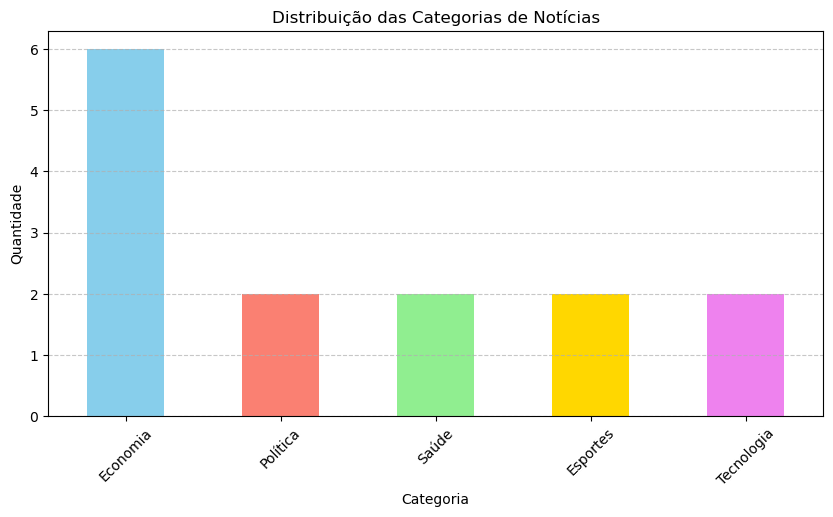

In [12]:
import matplotlib.pyplot as plt

# Contagem de categorias
contagem = df['categoria'].value_counts()

# Gráfico de barras
plt.figure(figsize=(10, 5))
contagem.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'gold', 'violet'])
plt.title('Distribuição das Categorias de Notícias')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

2. Nuvem de Palavras por Categoria

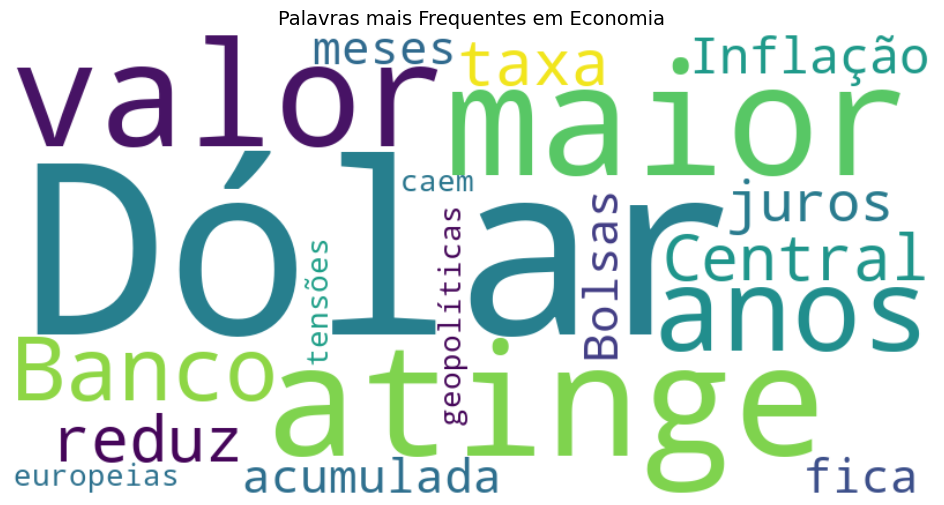

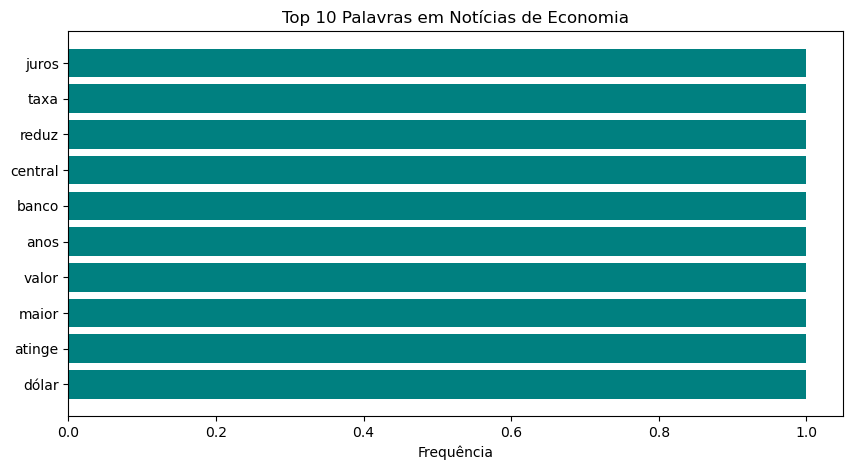

In [23]:
# 1. Instalação de pacotes (execute apenas uma vez)
!pip install wordcloud nltk pandas matplotlib --quiet

# 2. Importações e configurações
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import re
from collections import Counter

# Download das stopwords
nltk.download('stopwords', quiet=True)

# 3. Criar dataset de exemplo
data = {
    "texto": [
        "Senado aprova nova lei de proteção de dados",
        "Dólar atinge maior valor em 5 anos",
        "Banco Central reduz taxa de juros para 10,75%",
        "Inflação acumulada em 12 meses fica em 4,5%",
        "Bolsas europeias caem com tensões geopolíticas",
        "Ministério da Saúde lança campanha de vacinação",
        "Time de futebol contrata jogador por R$ 100 milhões"
    ],
    "categoria": ["Política", "Economia", "Economia", "Economia", "Economia", "Saúde", "Esportes"]
}

df = pd.DataFrame(data)

# 4. Preparar os dados
stop_words_pt = stopwords.words('portuguese') + ['é', 'para', 'dos', 'r']  # Stop words extendidas
texto_economia = ' '.join(df[df['categoria'] == 'Economia']['texto'])

# 5. Versão 1: Nuvem de palavras
try:
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words_pt,
        max_words=50
    ).generate(texto_economia)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Palavras mais Frequentes em Economia', size=14)
    plt.show()
except Exception as e:
    print(f"Erro ao gerar nuvem de palavras: {e}")

# 6. Versão 2: Gráfico de barras (alternativa)
palavras = re.findall(r'\w+', texto_economia.lower())
palavras_filtradas = [p for p in palavras if p not in stop_words_pt and len(p) > 3]
contagem = Counter(palavras_filtradas).most_common(10)

plt.figure(figsize=(10, 5))
plt.barh([p[0] for p in contagem], [p[1] for p in contagem], color='teal')
plt.title('Top 10 Palavras em Notícias de Economia')
plt.xlabel('Frequência')
plt.show()

3. Matriz de Confusão

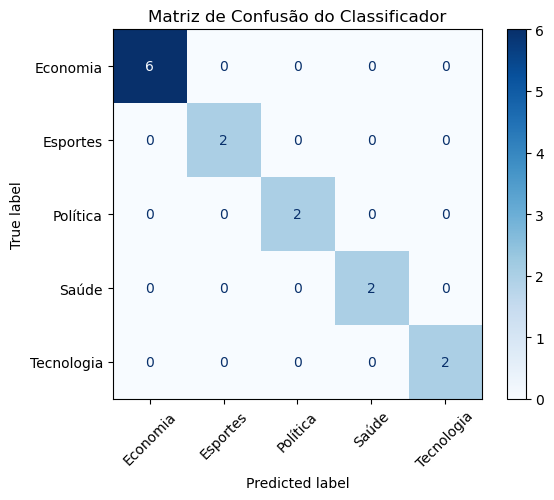

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prever todas as notícias do dataset
y_pred = model.predict(X)

# Gerar matriz
cm = confusion_matrix(y, y_pred, labels=model.classes_)

# Plotar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusão do Classificador')
plt.show()

4. Importância das Features (Top 10 Palavras)

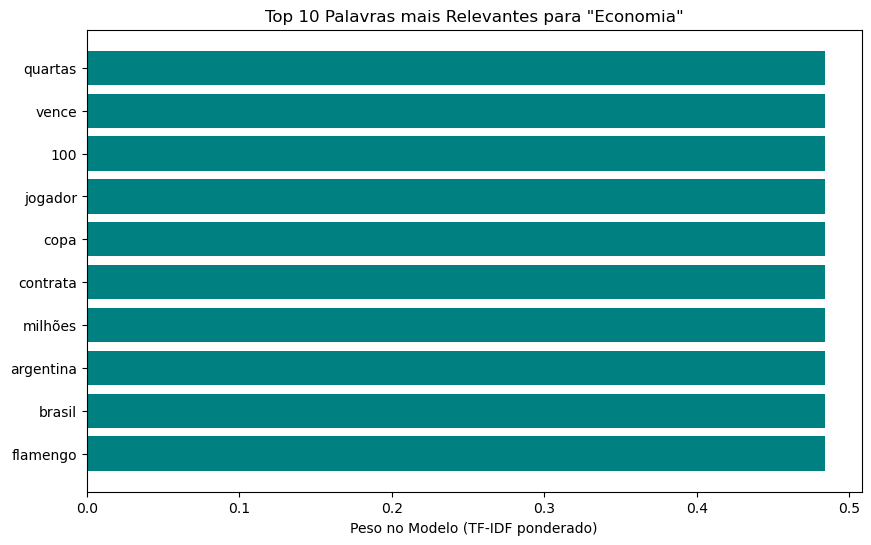

In [18]:
import numpy as np

# Pegar importância das features para a categoria "Economia"
importancias = model.coef_[1]  # Índice 1 = Economia
palavras = tfidf.get_feature_names_out()
top_indices = np.argsort(importancias)[-10:]  # Top 10

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(range(10), importancias[top_indices], color='teal')
plt.yticks(range(10), [palavras[i] for i in top_indices])
plt.title('Top 10 Palavras mais Relevantes para "Economia"')
plt.xlabel('Peso no Modelo (TF-IDF ponderado)')
plt.show()